<a href="https://colab.research.google.com/github/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning-Final-Project/blob/main/3916_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict how many hours users spend watching content on streaming platforms based on their demographics and viewing preferences?

**This is a prediction (umbrella) problem because:**
(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

This project focuses on predicting users’ watch time based on observable characteristics such as age, subscription type, and content preferences. The goal is to build a model that can capture patterns in user behavior and generate accurate predictions.

**The decision this enables:**
(Who is the stakeholder? What action would they take differently with your prediction?)

This analysis will be helpful for streaming media platforms, such as the Netflix dataset selected in this study, to determine how to achieve personalized content recommendations and optimize user engagement strategies. By predicting which users are more likely to spend more time on the platform, it can also help enterprises optimize content distribution and increase user retention rates.

**Dataset:** Netflix Users Database Dataset
- **Source:** Kaggle (URL: https://www.kaggle.com/datasets/smayanj/netflix-users-database/data)
- **N =** 25000
- **Features =** User_ID, Age, Country, Subscription_Type, Favorite_Genre, Last_Login, Watch_Time_Hours
- **Target variable =** Watch_Time_Hours
- **Access date:** April 17, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("smayanj/netflix-users-database")

print("Path to dataset files:", path)

100%|██████████| 354k/354k [00:00<00:00, 81.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/smayanj/netflix-users-database/versions/1


In [3]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

# df = pd.read_csv('your_data.csv')
df = pd.read_csv('https://raw.githubusercontent.com/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning-Final-Project/refs/heads/main/netflix_users.csv')

# Uncomment and modify one of the lines above
# df = pd.read_csv('___')

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (25000, 8)
Columns: ['User_ID', 'Name', 'Age', 'Country', 'Subscription_Type', 'Watch_Time_Hours', 'Favorite_Genre', 'Last_Login']


,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


### 2.2 Basic Description

In [4]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  int64  
 1   Name               25000 non-null  object 
 2   Age                25000 non-null  int64  
 3   Country            25000 non-null  object 
 4   Subscription_Type  25000 non-null  object 
 5   Watch_Time_Hours   25000 non-null  float64
 6   Favorite_Genre     25000 non-null  object 
 7   Last_Login         25000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.5+ MB


,User_ID,Age,Watch_Time_Hours
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,46.482880,500.468858
std,7217.022701,19.594861,286.381815
min,1.000000,13.000000,0.120000
25%,6250.750000,29.000000,256.567500
50%,12500.500000,46.000000,501.505000
75%,18750.250000,63.000000,745.732500
max,25000.000000,80.000000,999.990000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)


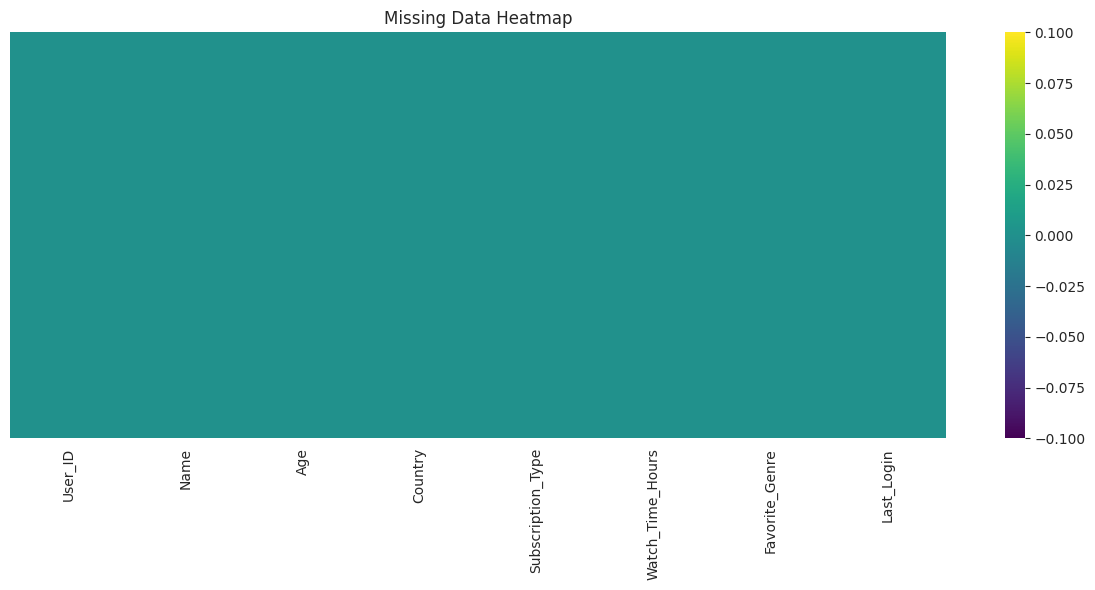

In [5]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# # Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** ___
(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)

This dataset has no missing values.Because there are no missing values, the data does not appear to present an MCAR, MAR, or MNAR issue in practice. Therefore, no missing-data treatment is needed.

### 2.4 Distribution Plots

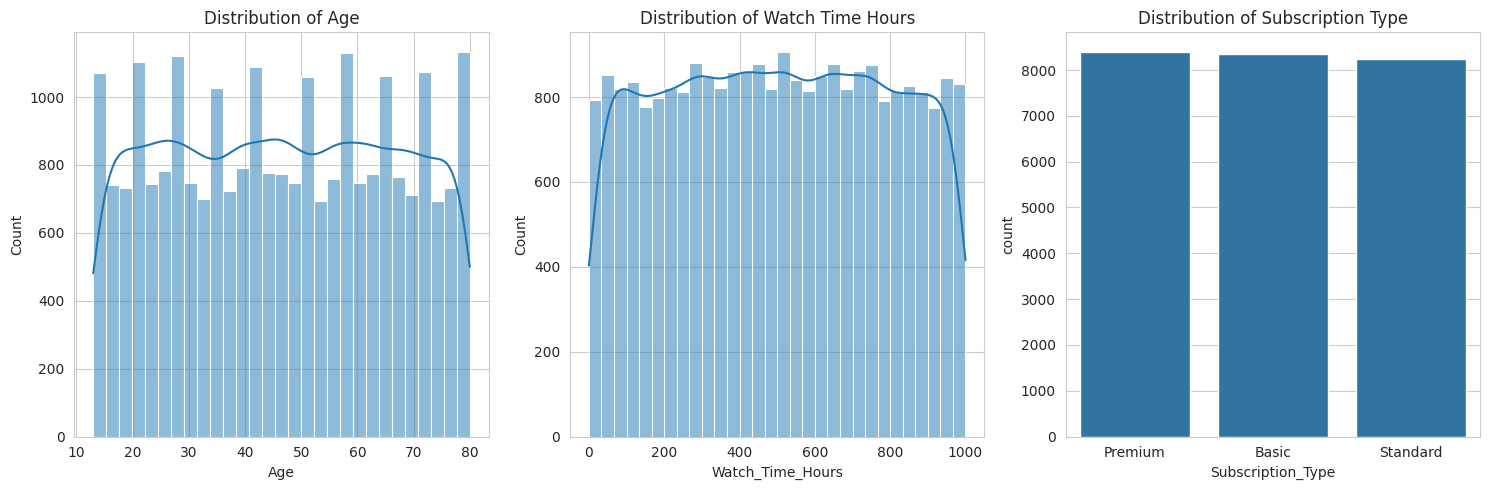

In [8]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# # Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')

sns.histplot(df['Watch_Time_Hours'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Watch Time Hours')

sns.countplot(x=df['Subscription_Type'], ax=axes[2])
axes[2].set_title('Distribution of Subscription Type')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [9]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
#     """Return lower and upper Tukey fences."""
     Q1 = series.quantile(0.25)
     Q3 = series.quantile(0.75)
     IQR = Q3 - Q1
     return Q1 - k * IQR, Q3 + k * IQR

# Example: check outliers in a numeric column
col = 'Age'
lower, upper = tukey_fences(df[col])
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

col = 'Watch_Time_Hours'
lower, upper = tukey_fences(df[col])
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

Age: 0 outliers (0.0%)
Watch_Time_Hours: 0 outliers (0.0%)


**Outlier strategy:** ___
(Trim? Winsorize? Keep with justification?)

All the outputs are 0. This is a very good phenomenon. There are no issues such as complete random missingness, partial random missingness, or non-random missingness in these data. Therefore, there is no need to handle the missing data.

### 2.6 Correlations

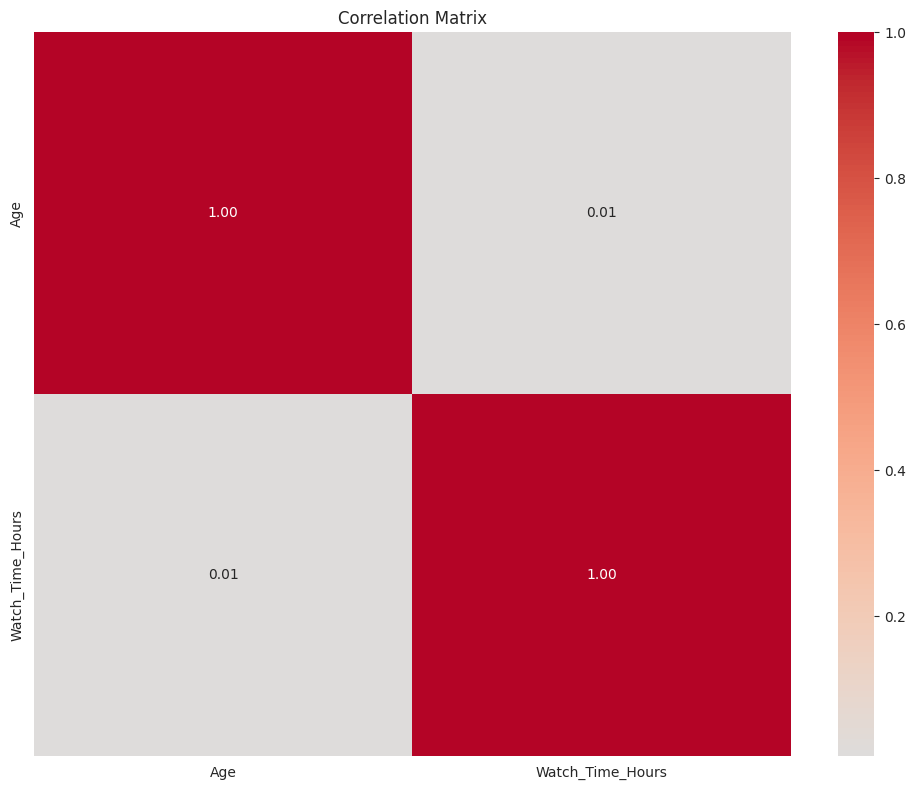

In [11]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('User_ID')
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

The variable "User ID" was not included in the correlation analysis because it is a unique identifier and does not contain meaningful information about user behavior. It neither provides valuable insights nor is it likely to be a useful factor; therefore, it is dropped. According to the correlation matrix, there is almost no linear relationship between age and viewing time, and the correlation coefficient is close to zero. This indicates that age alone cannot effectively predict user engagement and more variables may be needed to improve the prediction performance.

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable, watch time, is continuous and spread across a wide range of values. It does not follow a perfectly normal distribution, but it is not highly skewed. Therefore, no transformation is needed at this stage.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* Age shows almost no linear relationship with watch time, with a correlation close to zero. There are also no strong correlations between features, so multicollinearity does not appear to be a concern. This suggests that no single variable strongly predicts watch time on its own.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The dataset is very clean, with no missing values and no detected outliers. While this simplifies the analysis, it also suggests that the data may be synthetic and lacks real-world noise. No additional data cleaning is required at this stage.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 25000** observations and **M = 6** features.

**Missing data:** 0% of cells are missing.

**Outliers:** I identified 0 outliers using [Tukey Fences / IQR / visual inspection]. I will handle them by keeping all observations, since no extreme values were detected..

**Target variable:** The distribution of watch time shows a wide range across users, with no extreme skewness, making it suitable for regression analysis..

**Key finding from EDA:** User behavior appears to be influenced by multiple factors, and no single variable strongly predicts watch time on its own.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [24]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# # Define features and target
X = df[['Age', 'Country', 'Subscription_Type', 'Favorite_Genre']]  # Replace with your features
y = df['Watch_Time_Hours']  # Replace with your target
X = pd.get_dummies(X, drop_first=True)

# # For classification: use stratify=y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 20000 samples
Test:  5000 samples


### 3.2 Model 1: Baseline

In [40]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
# Choose a simple, interpretable baseline:
#   Classification: LogisticRegression
#   Regression: LinearRegression or Ridge

from sklearn.linear_model import LinearRegression  # or LinearRegression, Ridge
#
model_1 = LinearRegression()
model_1.fit(X_train, y_train)
#
y_pred_1 = model_1.predict(X_test)
#
# # Classification metrics
print('Model 1: Linear Regression')

#
# # Regression metrics (use these instead if regression)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

Model 1: Linear Regression
RMSE: 285.1058
MAE:  245.4170
R2:   -0.0004


### 3.3 Model 2: Your Choice

In [39]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
#   Classification: RandomForestClassifier, GradientBoostingClassifier
#   Regression: RandomForestRegressor, GradientBoostingRegressor

from sklearn.ensemble import RandomForestRegressor  # or RandomForestRegressor
#
model_2 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)
#
y_pred_2 = model_2.predict(X_test)
#
print('Model 2: Random Forest')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_2):.4f}")
print(f"R2: {r2_score(y_test, y_pred_2):.4f}")

Model 2: Random Forest
RMSE: 326.6938
MAE: 272.1935
R2: -0.3136


### 3.4 Cross-Validation Comparison

In [34]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# # Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# #                  'neg_mean_squared_error', 'r2' (regression)
scoring = 'r2'
#
cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
#
print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
#
# # Comparison table
comparison = pd.DataFrame({
     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
    f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
 })
comparison

Model 1 CV r2: -0.0014 +/- 0.0011
Model 2 CV r2: -0.3038 +/- 0.0142


,Model,CV r2 (mean),CV r2 (std)
0,Model 1 (Baseline),-0.001415,0.001061
1,Model 2 (Your Choice),-0.303774,0.014242


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
#
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
#
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
#
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___